# Installing Important Libraries

In [2]:
pip install pandas numpy matplotlib seaborn plotly statsmodels openpyxl

Note: you may need to restart the kernel to use updated packages.


# Loading and Checking data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load the dataset

df = pd.read_csv('owid-covid-data.csv')

# Initial inspection
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  object 
 1   continent                        44257 non-null  object 
 2   location                         44785 non-null  object 
 3   date                             44785 non-null  object 
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed

# Data Cleaning and Feature Engineering

In [3]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   iso_code                         44521 non-null  object        
 1   continent                        44257 non-null  object        
 2   location                         44785 non-null  object        
 3   date                             44785 non-null  datetime64[ns]
 4   total_cases                      44182 non-null  float64       
 5   new_cases                        43982 non-null  float64       
 6   new_cases_smoothed               43200 non-null  float64       
 7   total_deaths                     44182 non-null  float64       
 8   new_deaths                       43982 non-null  float64       
 9   new_deaths_smoothed              43200 non-null  float64       
 10  total_cases_per_million          43918 non-null  float64  

In [4]:
df.isnull().sum().sort_values(ascending=False)

new_tests                          29138
new_tests_per_thousand             29138
total_tests_per_thousand           28763
total_tests                        28763
tests_per_case                     28636
positive_rate                      28252
new_tests_smoothed                 27217
new_tests_smoothed_per_thousand    27217
tests_units                        26411
handwashing_facilities             26127
extreme_poverty                    18463
male_smokers                       13822
female_smokers                     13427
hospital_beds_per_thousand          8646
stringency_index                    7728
human_development_index             6227
aged_65_older                       5425
gdp_per_capita                      5343
aged_70_older                       5040
median_age                          4833
cardiovasc_death_rate               4818
diabetes_prevalence                 3419
population_density                  2283
new_deaths_smoothed_per_million     1650
new_cases_smooth

In [5]:
columns = [
    'continent',
    'location',
    'date',
    'total_cases',
    'new_cases',
    'total_deaths',
    'new_deaths',
    'population',
    'gdp_per_capita',
    'life_expectancy'
]

covid = df[columns].copy()

In [6]:
covid = covid[covid['continent'].notna()]

In [7]:
covid['death_rate'] = (
    covid['total_deaths'] /
    covid['total_cases']
) * 100

In [8]:
covid['infection_rate'] = (
    covid['total_cases'] /
    covid['population']
) * 100

In [9]:
covid['case_growth'] = covid.groupby('location')['new_cases'].pct_change()

C:\Users\angel\AppData\Local\Temp\ipykernel_8320\209167486.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  covid['case_growth'] = covid.groupby('location')['new_cases'].pct_change()


In [10]:
latest = covid.sort_values("date").groupby("location").tail(1)

latest.sort_values(
    "total_cases",
    ascending=False
).head(10)

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,population,gdp_per_capita,life_expectancy,death_rate,infection_rate,case_growth
42376,North America,United States,2020-09-19,6724667.0,50209.0,198589.0,956.0,3.310026e+08,54225.446,78.86,2.953143,2.031605,0.152455
18959,Asia,India,2020-09-19,5308014.0,93337.0,85619.0,1247.0,1.380004e+09,6426.674,69.66,1.613014,0.384637,-0.032015
6025,South America,Brazil,2020-09-19,4495183.0,39797.0,135793.0,858.0,2.125594e+08,14103.452,75.88,3.020856,2.114789,0.096245
33573,Europe,Russia,2020-09-19,1091186.0,5905.0,19195.0,134.0,1.459345e+08,24765.954,72.58,1.759095,0.747723,0.024818
31940,South America,Peru,2020-09-19,756412.0,6314.0,31283.0,137.0,3.297185e+07,12236.706,76.74,4.135709,2.294115,0.108108
9074,South America,Colombia,2020-09-19,750471.0,6526.0,23850.0,185.0,5.088288e+07,13254.949,77.29,3.178004,1.474899,-0.137685
26596,North America,Mexico,2020-09-19,688954.0,4841.0,72803.0,624.0,1.289328e+08,17336.469,75.05,10.567179,0.534351,0.521370
36982,Africa,South Africa,2020-09-19,657627.0,2055.0,15857.0,85.0,5.930869e+07,12294.876,64.13,2.411245,1.108821,-0.034305
37676,Europe,Spain,2020-09-18,640040.0,14389.0,30495.0,90.0,4.675478e+07,34272.360,83.56,4.764546,1.368929,0.274378
1683,South America,Argentina,2020-09-19,601700.0,12701.0,12491.0,262.0,4.519578e+07,18933.907,76.67,2.075951,1.331319,0.087973


In [11]:
latest.sort_values(
    "total_deaths",
    ascending=False
).head(10)

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,population,gdp_per_capita,life_expectancy,death_rate,infection_rate,case_growth
42376,North America,United States,2020-09-19,6724667.0,50209.0,198589.0,956.0,3.310026e+08,54225.446,78.86,2.953143,2.031605,0.152455
6025,South America,Brazil,2020-09-19,4495183.0,39797.0,135793.0,858.0,2.125594e+08,14103.452,75.88,3.020856,2.114789,0.096245
18959,Asia,India,2020-09-19,5308014.0,93337.0,85619.0,1247.0,1.380004e+09,6426.674,69.66,1.613014,0.384637,-0.032015
26596,North America,Mexico,2020-09-19,688954.0,4841.0,72803.0,624.0,1.289328e+08,17336.469,75.05,10.567179,0.534351,0.521370
42112,Europe,United Kingdom,2020-09-19,385936.0,4322.0,41732.0,27.0,6.788600e+07,39753.244,81.32,10.813192,0.568506,0.273049
20726,Europe,Italy,2020-09-19,294932.0,1907.0,35668.0,10.0,6.046183e+07,35220.084,83.51,12.093635,0.487799,0.204675
31940,South America,Peru,2020-09-19,756412.0,6314.0,31283.0,137.0,3.297185e+07,12236.706,76.74,4.135709,2.294115,0.108108
14636,Europe,France,2020-09-19,428696.0,13215.0,31249.0,154.0,6.527351e+07,38605.671,82.66,7.289315,0.656769,0.247522
37676,Europe,Spain,2020-09-18,640040.0,14389.0,30495.0,90.0,4.675478e+07,34272.360,83.56,4.764546,1.368929,0.274378
19487,Asia,Iran,2020-09-19,416198.0,3049.0,23952.0,144.0,8.399295e+07,19082.620,76.68,5.754953,0.495515,0.083126


In [12]:
latest.sort_values(
    "infection_rate",
    ascending=False
).head(10)

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,population,gdp_per_capita,life_expectancy,death_rate,infection_rate,case_growth
33045,Asia,Qatar,2020-09-19,122917.0,224.0,209.0,1.0,2881060.0,116935.600,80.23,0.170033,4.266381,-0.081967
3375,Asia,Bahrain,2020-09-19,63189.0,705.0,219.0,3.0,1701583.0,43290.705,77.29,0.346579,3.713542,-0.161712
2133,North America,Aruba,2020-09-19,3460.0,78.0,23.0,0.0,106766.0,35973.781,76.29,0.664740,3.240732,0.444444
31355,North America,Panama,2020-09-19,104879.0,741.0,2229.0,16.0,4314768.0,22267.037,78.51,2.125306,2.430698,0.102679
8611,South America,Chile,2020-09-19,442827.0,1677.0,12199.0,57.0,19116209.0,22767.037,80.18,2.754800,2.316500,-0.099839
22405,Asia,Kuwait,2020-09-19,98528.0,704.0,580.0,4.0,4270563.0,65530.537,75.49,0.588665,2.307143,-0.146667
31940,South America,Peru,2020-09-19,756412.0,6314.0,31283.0,137.0,32971846.0,12236.706,76.74,4.135709,2.294115,0.108108
34579,Europe,San Marino,2020-09-19,723.0,0.0,42.0,0.0,33938.0,56861.470,84.97,5.809129,2.130355,NaN
6025,South America,Brazil,2020-09-19,4495183.0,39797.0,135793.0,858.0,212559409.0,14103.452,75.88,3.020856,2.114789,0.096245
20462,Asia,Israel,2020-09-19,179071.0,2138.0,1196.0,27.0,8655541.0,33132.320,82.97,0.667892,2.068860,-0.586060


# Making Visuals

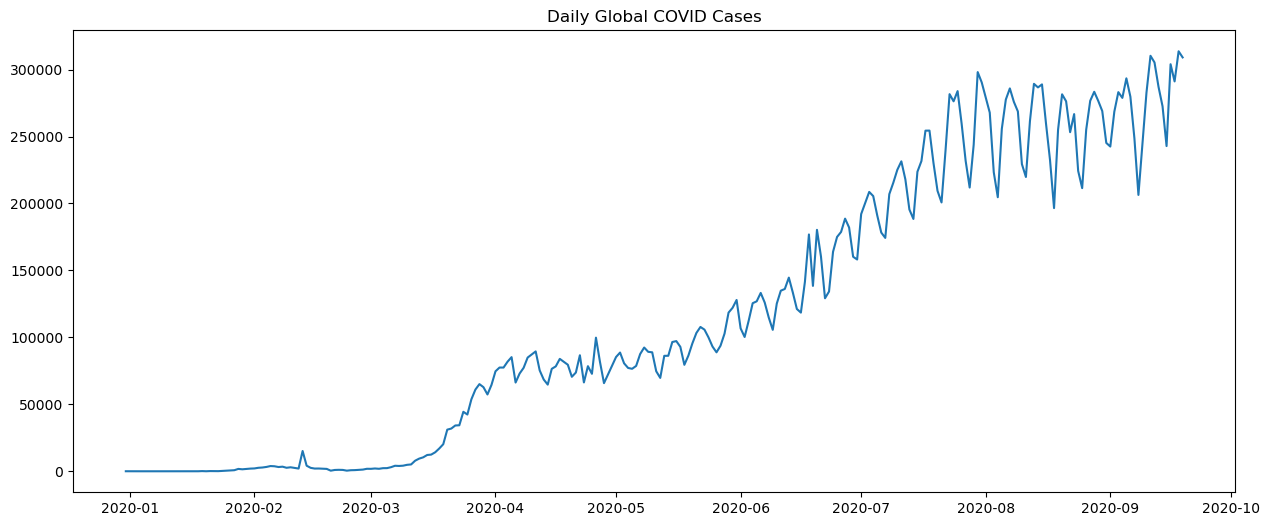

In [13]:
global_cases = covid.groupby("date")["new_cases"].sum()

plt.figure(figsize=(15,6))

plt.plot(global_cases)

plt.title("Daily Global COVID Cases")

plt.show()

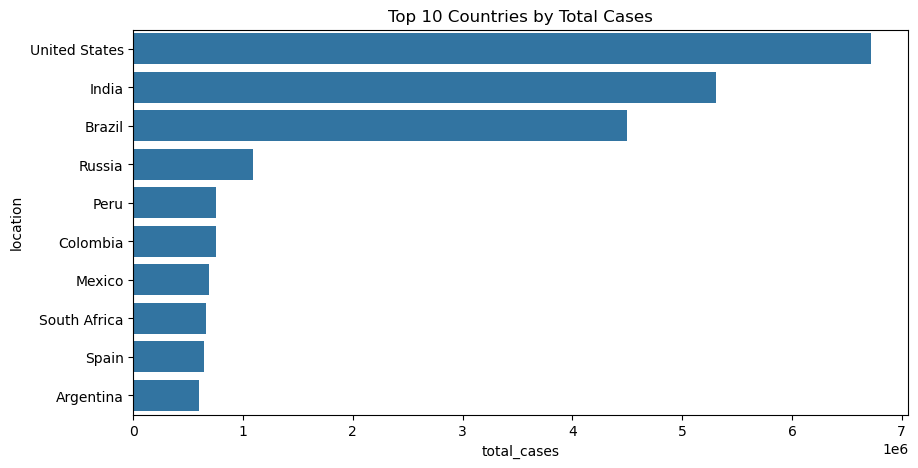

In [15]:
top10 = latest.nlargest(10, 'total_cases')

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x='total_cases',
    y='location'
)

plt.title("Top 10 Countries by Total Cases")

plt.show()

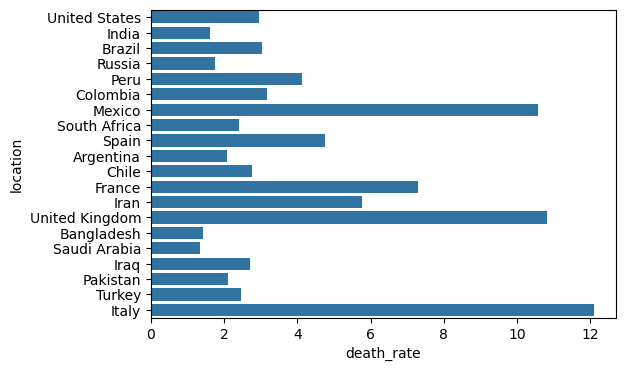

In [18]:
top = latest.nlargest(20, 'total_cases')

plt.figure(figsize=(6,4))

sns.barplot(
    data=top,
    x='death_rate',
    y='location'
)

plt.show()

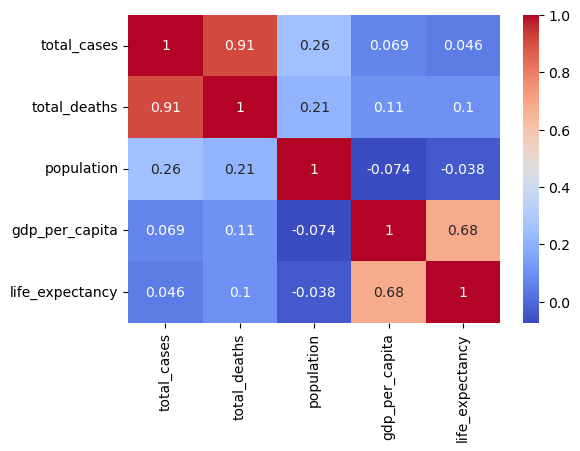

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    covid[
        ['total_cases',
         'total_deaths',
         'population',
         'gdp_per_capita',
         'life_expectancy']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [22]:
pakistan = covid[covid.location=="Pakistan"]

pakistan['MA7'] = (
    pakistan['new_cases']
    .rolling(7)
    .mean()
)

C:\Users\angel\AppData\Local\Temp\ipykernel_8320\3409655559.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pakistan['MA7'] = (


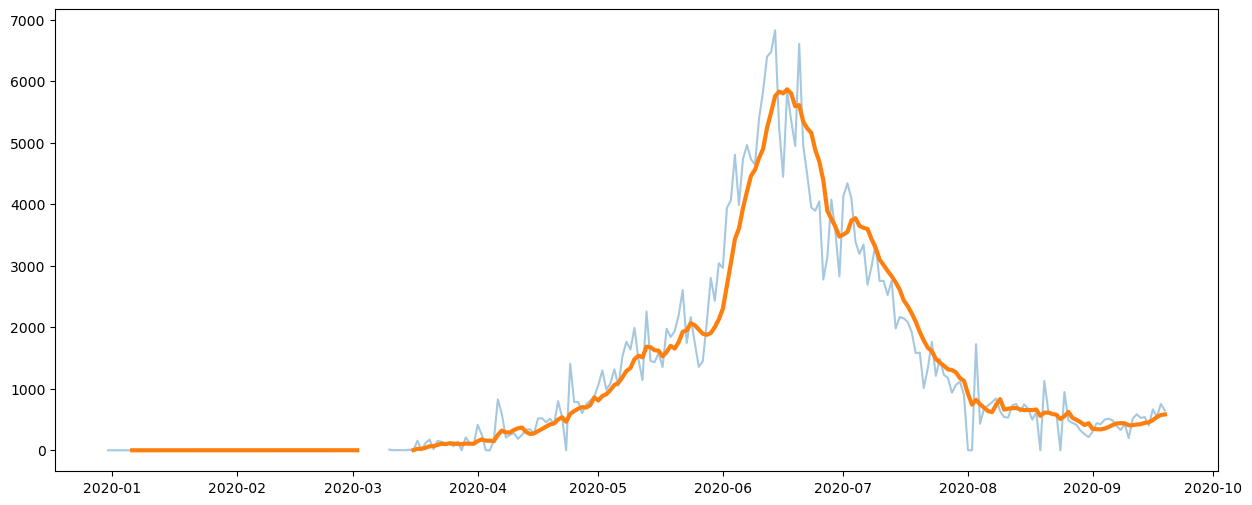

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    pakistan['date'],
    pakistan['new_cases'],
    alpha=0.4
)

plt.plot(
    pakistan['date'],
    pakistan['MA7'],
    linewidth=3
)

plt.show()

In [24]:
# Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

series = pakistan['new_cases'].fillna(0)

model = ExponentialSmoothing(
    series,
    trend='add'
)

fit = model.fit()

forecast = fit.forecast(30)

C:\Users\angel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\angel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\angel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


C:\Users\angel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


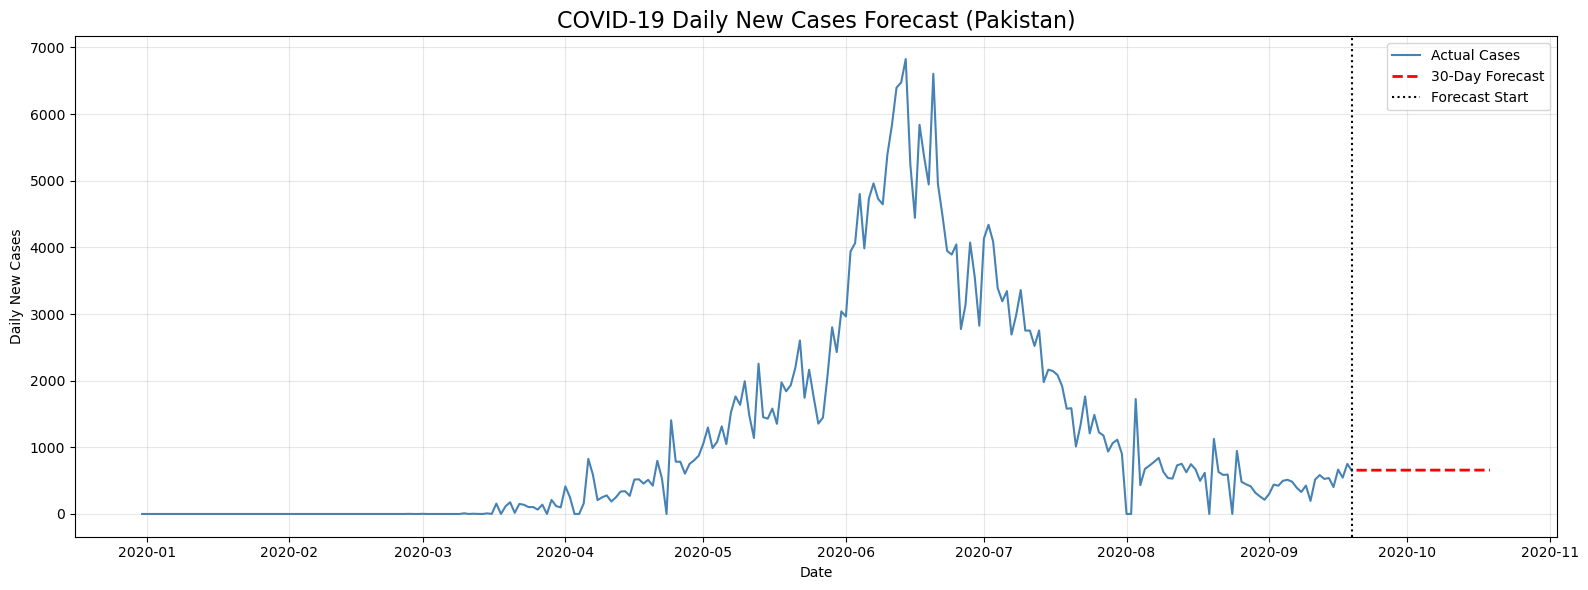

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Select country
pakistan = covid[covid['location'] == 'Pakistan'].copy()

# Fill missing values
pakistan['new_cases'] = pakistan['new_cases'].fillna(0)

# Use date as index
pakistan.set_index('date', inplace=True)

# Build the model
model = ExponentialSmoothing(
    pakistan['new_cases'],
    trend='add',
    seasonal=None
)

fit = model.fit()

# Forecast next 30 days
forecast = fit.forecast(30)

# Create forecast dates
forecast_dates = pd.date_range(
    start=pakistan.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

forecast.index = forecast_dates

# Plot
plt.figure(figsize=(16,6))

# Historical data
plt.plot(
    pakistan.index,
    pakistan['new_cases'],
    label='Actual Cases',
    color='steelblue'
)

# Forecast
plt.plot(
    forecast.index,
    forecast,
    label='30-Day Forecast',
    color='red',
    linestyle='--',
    linewidth=2
)

# Mark where forecast begins
plt.axvline(
    x=pakistan.index[-1],
    color='black',
    linestyle=':',
    label='Forecast Start'
)

plt.title('COVID-19 Daily New Cases Forecast (Pakistan)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily New Cases')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

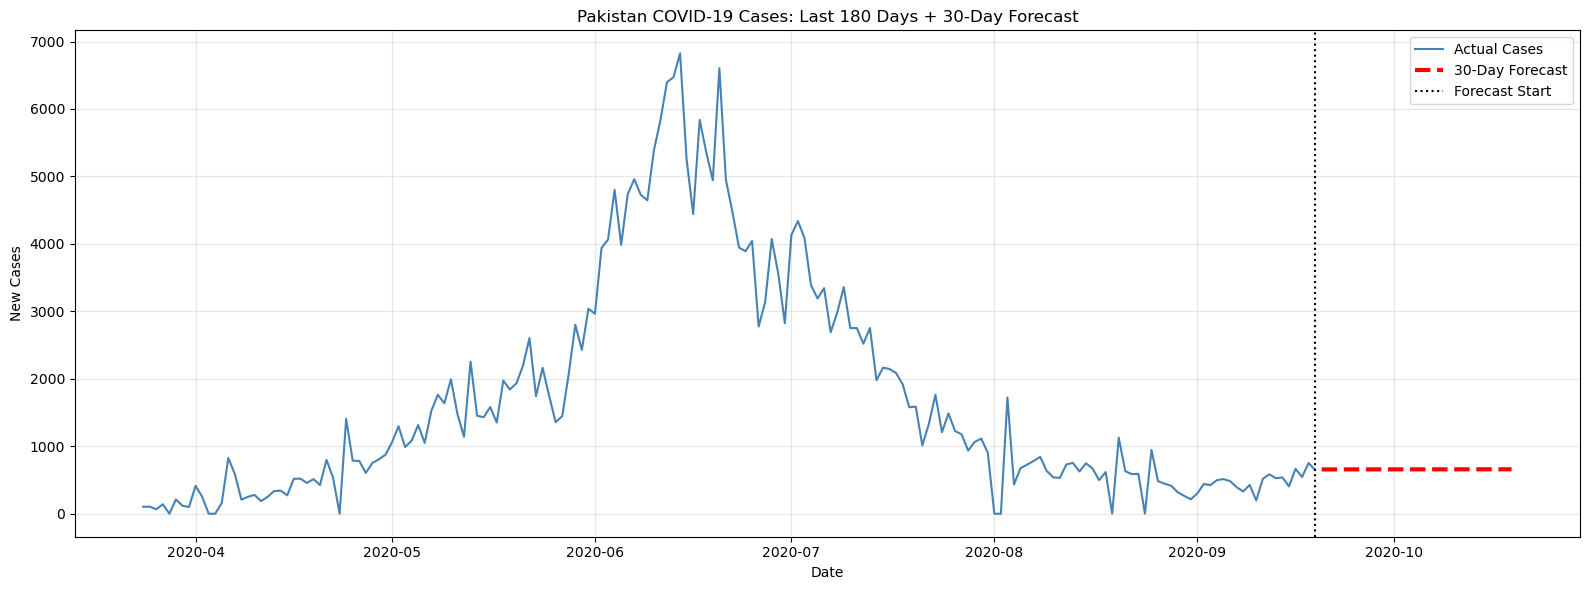

In [26]:
plt.figure(figsize=(16,6))

# Last 180 days
recent = pakistan.iloc[-180:]

plt.plot(
    recent.index,
    recent['new_cases'],
    label='Actual Cases',
    color='steelblue'
)

plt.plot(
    forecast.index,
    forecast,
    '--',
    color='red',
    linewidth=3,
    label='30-Day Forecast'
)

plt.axvline(
    x=recent.index[-1],
    color='black',
    linestyle=':',
    label='Forecast Start'
)

plt.title('Pakistan COVID-19 Cases: Last 180 Days + 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Downloading clean dataset for further Analysis

In [27]:
covid.to_csv("covid_clean.csv", index=False)